# Personal Project: Hospital Provider Cost Reports

## Exploratory Data Analysis on Hospital Provider Cost Reports

### Introduction
This project analyzes **Hospital Provider Cost Reports** published between 2011 and 2022. The dataset includes annual hospital cost reporting files, which were combined into a single consolidated dataset for analysis.

Our primary objective is to perform a comprehensive analysis of hospital provider cost report data to identify patterns, trends, and potential areas for improvement. This work will serve as a learning exercise to strengthen my data analysis skills and will result in a polished portfolio piece showcasing my ability to transform raw data into actionable insights.

📂 **Data Source**: [CMS Hospital Provider Cost Report](https://data.cms.gov/provider-compliance/cost-report/hospital-provider-cost-report)

---
### Research Questions
The following questions guide the analysis of hospital cost report data, with emphasis on financial performance, capacity, and care delivery trends across hospitals and regions.  

Financial Performance
- How has hospital net income changed over time, both nationally and by state?
- What is the average cost-to-charge ratio across hospitals, and which hospitals are outliers?
- How has the cost-to-charge ratio evolved over the years?
- How do urban vs. rural hospitals differ in financial performance trends?
- What are the long-term trends in assets, liabilities, and fund balances?

Capacity & Operations
- Which states or counties have the highest hospital capacity in terms of beds and patient days?
- How has staffing (FTE employees) changed relative to patient volume?

Care Delivery & Equity
- What are the trends in charity care and uncompensated care over time?
- How much uncompensated care is provided by region or hospital type?
- How do inpatient vs. outpatient revenues vary by hospital size and type?

---
### Who is the intended audience?
The insights will be tailored to meet the needs of several stakeholder groups:
- Hospital administrators and executives – to inform operational and financial decision-making
- Researchers & analysts – to serve as a reference point for further studies
- General public & patient advocates – to promote understanding of healthcare costs and trends
- Policy makers and government agencies – to guide regulation, funding allocation, and healthcare reform initiatives

### Type of Analyses
Descriptive analysis:
- Visualize cost distribution by department and facility characteristics
- Analyze Medicare settlement trends and utilization data
- Explore patterns that might indicate cost drivers or inefficiencies

Financial insights:
- Highlight key KPIs like cost-to-reimbursement ratios
- Detect and flag unusual cost spikes or trends in expenses
- Provide easy-to-understand summaries for quick decision-making

Marketing/strategy angle:
- Benchmark facilities against each other on cost efficiency
- Show utilization strengths in high-demand services
- Present geographic and service-line heatmaps for competitive insights

---
### Preparing the Environment

We will import the required libraries and read in the data set.
- Pandas - Data Manipulation
- Matplotlib - Data Visualization
- Seaborn - Data Visualization
- Warnings - Utility usage libraries

In [1]:
# Import libraries and alias for easy reading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

In [2]:
# Suppress all warning messages to keep the output clean
warnings.filterwarnings('ignore')

# Configure plot styles: use matplotlib's default style
plt.style.use("default")

# Apply seaborn's theme for better-looking plots
sns.set_theme()

# Display all columns when printing DataFrames
pd.set_option("display.max_columns", None)

# Set the number of decimal places to display in DataFrames
pd.set_option("display.precision", 2)

In [3]:
# File path for the CSV data (replace with your own path if needed)
file_path = "C:/Users/Jason/Documents/Documents/Projects/Hospital_Provider_Cost_Report/Data/interim/hospital_provider_cost_output.csv"

# Read/load data in CSV format into a pandas DataFrame for analysis
hospital_provider_cost_data_raw = pd.read_csv(file_path)

---
### Data Source & Preparation

The dataset comes from annual Hospital Provider Cost Reports, published between 2011 and 2022. Each year was originally provided as a separate CSV file (such as `CostReport_2011_Final.csv`, `CostReport_2012_Final.csv`, `CostReport_2022_Final.csv`).  

To simplify the analysis, these files were combined into a **single consolidated dataset**.  
A preprocessing script (`merge_hospital_provider_cost_report_data.py`) was used to:
- Load all CSV files from 2011–2022
- Extract the year from the filename
- Add a new column `Cost Report Year`
- Merge them into one unified dataset
- Save the result as `hospital_provider_cost_output.csv`

This consolidated file is what we use for all further analysis.

---

### Data Exploration
Let's have a look at the data using df.head() and df.tail() function.

In [4]:
# Display the first 5 rows of the dataset
hospital_provider_cost_data_raw.head()

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
0,285,10005,MARSHALL MEDICAL CENTER - SOUTH,2505 U.S. HIGHWAY 431,BOAZ,AL,35957-,MARSHALL,13820.0,R,STH,1,9,10/01/2010,09/30/2011,598.72,NaN,NaN,9132.0,4591.0,19641.0,114.0,41610.0,NaN,2109.0,1134.0,5283.0,114.0,NaN,7508.0,3073.0,15068.0,102.0,37230.0,NaN,2109.0,1134.0,5283.0,1.31e+06,NaN,1.13e+06,1.44e+06,2.67e+07,4.47e+07,5.08e+06,5.80e+07,6.86e+07,1.39e+08,2.08e+08,6.97e+06,NaN,2.67e+07,983584.0,NaN,NaN,6.88e+06,NaN,NaN,6.38e+06,NaN,564530.0,190283.0,1.30e+06,1.53e+07,1.97e+06,2.70e+06,7.63e+07,NaN,6.32e+06,4.93e+07,42937.0,NaN,5.65e+07,NaN,3.75e+07,3.75e+07,1.09e+08,4.10e+06,2.60e+06,NaN,NaN,NaN,-5.69e+06,1.01e+06,1.29e+07,NaN,NaN,4.81e+04,1.30e+07,1.40e+07,9.53e+07,9.53e+07,1.09e+08,1.27e+07,NaN,NaN,23664.0,2.18e+06,0.17,NaN,NaN,7.07e+07,1.50e+08,2.21e+08,1.58e+08,6.33e+07,7.13e+07,-8.02e+06,5.33e+06,-2.69e+06,NaN,-2.69e+06,0.28,8.36e+06,3.06e+

In [5]:
# Display the last 5 rows of the dataset
hospital_provider_cost_data_raw.tail()

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
73969,776749,251325,COVINGTON COUNTY HOSPITAL,803 GERALD MCRANEY DRIVE,COLLINS,MS,39428,COVINGTON,25620.0,U,CAH,1,9,10/01/2021,09/30/2022,263.92,NaN,NaN,3316.0,1.0,4872.0,25.0,9125.0,NaN,64.0,11.0,124.0,35.0,NaN,235.0,1.0,441.0,25.0,9125.0,NaN,64.0,11.0,124.0,1.00e+00,8.21e+04,2.87e+04,7.10e+05,2.04e+07,2.20e+07,6.71e+05,3.07e+07,9.29e+06,4.45e+07,5.38e+07,NaN,NaN,NaN,NaN,NaN,NaN,7.85e+06,NaN,NaN,1.04e+07,-5.93e+06,8.71e+05,3.09e+05,1.18e+06,1.53e+07,2.90e+05,NaN,NaN,NaN,NaN,1.07e+07,NaN,NaN,1.12e+07,NaN,NaN,NaN,2.65e+07,6.85e+05,NaN,NaN,8.20e+05,NaN,2.86e+06,4.37e+06,NaN,5.18e+06,NaN,NaN,5.18e+06,9.55e+06,1.70e+07,1.70e+07,2.65e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.72e+07,4.60e+07,6.32e+07,2.96e+07,3.37e+07,4.25e+07,-8.84e+06,9.72e+06,8.84e+05,NaN,8.84e+05,0.57,1.26e+06,3.99e+06,NaN,NaN,2022
73970,776764,330273,PUTNAM HOSPITAL CENTER,670 STONELEIGH

You can see that the dataset contains a mix of categorical, geographical, and numerical variables.

Each record (row) corresponds to a hospital’s annual Medicare cost report submission for a specific fiscal year. The dataset captures:

- Operational statistics (beds, employees, interns/residents)
- Utilization metrics (patient days, discharges, inpatient vs. outpatient activity)
- Financial performance (costs, charges, revenues, charity care, uncompensated care, net income)
- Geographical details (city, state, county, rural vs. urban classification)
- Organizational attributes (facility type, ownership/control type, teaching status)

Next, we will use df.shape and df.info() to explore the dataset’s dimensions and variable types in more detail.

---

### Data Validation

In this step, I validated the integrity and structure of the dataset before cleaning. Validation tasks included:  
- Checking the shape of the dataset (rows and columns)  
- Reviewing column names and data types  
- Generating descriptive statistics for numerical fields  
- Summarizing the dataset (info, unique values, distributions)  
- Counting missing values per column and calculating percentages  

These checks ensure the dataset is complete, consistent, and properly structured before proceeding with cleaning and analysis.

In [6]:
# Shape of the data set (rows, columns)
print("Shape of dataset:", hospital_provider_cost_data_raw.shape)

Shape of dataset: (73974, 118)


In [7]:
# Summarised information of data set
hospital_provider_cost_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73974 entries, 0 to 73973
Columns: 118 entries, rpt_rec_num to Cost Report Year
dtypes: float64(103), int64(5), object(10)
memory usage: 66.6+ MB


There are 73,974 rows including header and 118 columns. Data type is correct and matches the corresponding values.

In [8]:
# Column names and data types
print("\nColumn Info:")
print(hospital_provider_cost_data_raw.dtypes)


Column Info:
rpt_rec_num                            int64
Provider CCN                           int64
Hospital Name                         object
Street Address                        object
City                                  object
                                      ...   
Net Revenue from Medicaid            float64
Medicaid Charges                     float64
Net Revenue from Stand-Alone CHIP    float64
Stand-Alone CHIP Charges             float64
Cost Report Year                       int64
Length: 118, dtype: object


---

### Descriptive Statistics

Here, we will do a descriptive statistical analysis. We use df.describe() and assign 'include = 'all' to ensure that categorical features are also included in the output.

In [9]:
# Get descriptive statistics summary
hospital_provider_cost_data_raw.describe(include = "all")

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
count,73974.00,73974.00,73974,73916,73974,73974,73974,70162,73048.00,73048,73974,73974.00,73974.00,73974,73974,72518.00,16015.00,2443.00,72404.00,63357.00,72894.00,7.30e+04,7.30e+04,2349.00,72444.00,62840.00,72882.00,7.30e+04,2262.00,72325.00,62766.00,72867.00,7.29e+04,7.30e+04,2349.00,72444.00,62840.00,72882.00,5.27e+04,5.51e+04,5.87e+04,5.89e+04,7.30e+04,7.30e+04,7.23e+04,7.30e+04,7.30e+04,6.75e+04,7.30e+04,4.49e+04,4.68e+03,4.84e+04,3.85e+04,4.80e+03,9.16e+03,6.80e+04,1.55e+04,3.69e+03,6.96e+04,5.02e+04,6.31e+04,6.06e+04,3.25e+04,7.04e+04,5.11e+04,4.65e+04,6.12e+04,3.29e+04,4.10e+04,6.30e+04,1.22e+04,6.42e+03,6.98e+04,2.98e+04,5.58e+04,6.14e+04,7.06e+04,6.95e+04,6.31e+04,2.72e+04,3.46e+04,1.07e+04,5.94e+04,7.03e+04,1.03e+04,3.07e+04,3.37e+03,4.57e+04,6.09e+04,7.03e+04,7.04e+04,7.05e+04,7.06e+04,7.64e+03,2.68e+04,3.18e+04,2.49e+04,3.36e+04,33942.0

You will see 'NaN' in some of the categorical columns and that's perfectly fine. Categorical values like hospital name, county, or provider type are not meant to have calculations performed on them, so we can ignore those for numeric analysis.

What we want to focus on is the unique count and distribution of these categorical features, such as:  

- There are 9,118 unique hospitals across 56 states/territories and nearly 5,795 counties. Most hospitals are urban (44,409) compared to rural (29,048).  
- Hospitals vary in type and control, with a mix of acute care, rehabilitation, and specialty facilities.  

For numerical features, it's interesting to note that:  

- Median hospital beds are around 836, but some hospitals report extremely high bed counts due to combined subproviders.  
- Total assets and net income vary widely, with some hospitals reporting negative income in the billions, highlighting potential data cleaning or extreme cases.  
- Cost-to-charge ratios range from 0.12 up to 1.33, indicating large differences in operational efficiency.  

We will perform analysis below to explore these observations further, focusing on financial performance, capacity, and care delivery trends.

In [10]:
# Count of missing values per column
print("\nMissing Values per Column:")
print(hospital_provider_cost_data_raw.isnull().sum())


Missing Values per Column:
rpt_rec_num                              0
Provider CCN                             0
Hospital Name                            0
Street Address                          58
City                                     0
                                     ...  
Net Revenue from Medicaid            19492
Medicaid Charges                     19517
Net Revenue from Stand-Alone CHIP    61937
Stand-Alone CHIP Charges             61756
Cost Report Year                         0
Length: 118, dtype: int64


In [11]:
# Percentage of missing values
print("\nPercentage Missing:")
print((hospital_provider_cost_data_raw.isnull().sum() / len(hospital_provider_cost_data_raw) * 100).round(2))


Percentage Missing:
rpt_rec_num                           0.00
Provider CCN                          0.00
Hospital Name                         0.00
Street Address                        0.08
City                                  0.00
                                     ...  
Net Revenue from Medicaid            26.35
Medicaid Charges                     26.38
Net Revenue from Stand-Alone CHIP    83.73
Stand-Alone CHIP Charges             83.48
Cost Report Year                      0.00
Length: 118, dtype: float64


---

### Data Cleaning & Preprocessing

Before conducting exploratory data analysis (EDA), it was necessary to ensure the dataset was accurate, consistent, and ready for analysis.  
Raw healthcare provider data often contained missing values, inconsistent formatting, duplicate records, non-standard codes, and accounting sign conventions in financial fields.

The cleaning and preprocessing process addressed these issues through the following steps:

- Handling missing and blank values  
- Standardizing categorical fields (such as county, provider type, rural vs. urban)  
- Correcting formatting issues in ZIP codes and addresses  
- Removing or replacing invalid or corrupted entries  
- Expanding abbreviations and replacing numeric codes with descriptive labels  
- Validating numerical fields, correcting sign conventions, and rounding where appropriate  
- Recalculating totals from cleaned sub-accounts to ensure balance sheet integrity  

To demonstrate versatility, I applied a **hybrid approach using both Excel and Python**:
- **Excel** was used for quick inspection and manual cleaning of categorical and text-based fields (such as addresses, county names, ZIP codes, provider type mappings).  
- **Python (Pandas)** was used for scalable, reproducible cleaning of large datasets, particularly financial fields (such as standardizing revenue and expense signs, recalculating totals, and applying consistent rules across multiple years).  

*Data Cleaning Workflow*

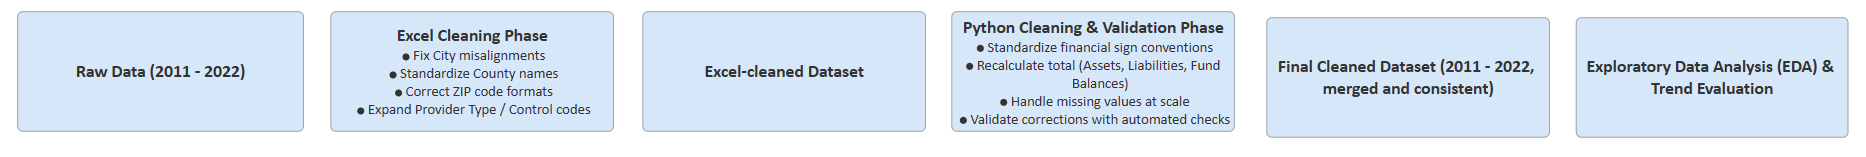

**Note on Workflow:**

- The initial round of cleaning was performed in **Excel** to address text-based and categorical issues:  
  - City misalignment  
  - ZIP code formatting  
  - County standardization  

- The **Excel-cleaned dataset** was then imported into **Python** for additional cleaning, validation, and scalable preprocessing, including:  
  - Handling financial sign conventions  
  - Recalculating totals (Assets, Liabilities, Fund Balances)  
  - Running quality checks across all reporting years  

- This hybrid process ensured:  
  - **Transparency** → Excel for visual inspection and manual corrections  
  - **Reproducibility** → Python for systematic, programmatic cleaning  

- By combining Excel’s strengths in inspection with Python’s automation and validation, I produced a **merged dataset (2011–2022)** that is consistent and reliable.  

- The cleaned dataset provides a solid foundation for **exploratory data analysis (EDA)** and **trend evaluation** in the following sections.

---
#### City Column Cleanup
During validation, I discovered that the **City** column contained some full street addresses due to a misaligned import.  

**Steps Taken in Excel**  
1. Applied the filter option to review distinct values in the City column.  
2. Performed a quick scan to identify values that looked like addresses instead of city names.  
3. For affected records, manually realigned the fields:  
   - Moved the address from the City column back into the Street Address column.  
   - Cleared the incorrect value in City.  
4. Repopulated City where possible using ZIP → City crosswalks, and spot-checked ambiguous cases using Google Maps for verification.  

Before: Misaligned City Values (Raw Data)

Some provider records contained full street addresses in the **City** column due to a misaligned import. The table below displays the affected **Provider CCN IDs** (`50262`, `50751`, `100017`) with selected attributes to illustrate the issue. Notice that the **City** field incorrectly contains address values, while the **Street Address** field contains hospital names.


In [12]:
# === BEFORE: Show misaligned City values (raw data) ===
# Goal: Display only the affected providers and the key fields to illustrate the issue.

# Columns to display
cols = ["rpt_rec_num", "Provider CCN", "Hospital Name", "Street Address", "City", "State Code"]

# Provider CCNs with suspected misalignment
affected_ccns = [50262, 50751, 100017]

# Filter to affected providers (raw data)
before_view = (hospital_provider_cost_data_raw.loc[hospital_provider_cost_data_raw["Provider CCN"].isin(affected_ccns), cols].sort_values(by=["Provider CCN", "City"]).reset_index(drop=True))

before_view

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code
0,763398,50262,RONALD REAGAN UCLA MEDICAL CENTER,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,CA
1,700191,50262,RONALD REAGAN UCLA MEDICAL CENTER,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,CA
2,764372,50262,RONALD REAGAN UCLA MEDICAL CENTER,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,CA
3,763807,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
4,546554,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
5,773512,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
6,742300,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
7,764373,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
8,762025,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
9,739947,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA


In [13]:
# === Load Cleaned Dataset ===
# File path for the cleaned CSV (update if needed for your environment)
file_path_cleaned = ("C:/Users/Jason/Documents/Documents/Projects/Hospital_Provider_Cost_Report/Data/interim/hospital_provider_cost_output_cleaned.csv")

# Read the cleaned data into a pandas DataFrame for analysis
hospital_provider_cost_data_clean = pd.read_csv(file_path_cleaned)

In [14]:
# === AFTER: Verify City is corrected (post-cleaning) ===

after_view = (hospital_provider_cost_data_clean.loc[hospital_provider_cost_data_clean["Provider CCN"].isin(affected_ccns), cols].sort_values(by=["Provider CCN", "City"]).reset_index(drop=True))

after_view

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code
0,546554,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
1,700191,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
2,739947,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
3,742300,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
4,759418,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
5,762025,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA
6,763398,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
7,763807,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
8,764372,50262,RONALD REAGAN UCLA MEDICAL CENTER,757 WESTWOOD PLAZA,LOS ANGELES,CA
9,764373,50262,RONALD REAGAN UCLA,757 WESTWOOD PLAZA,LOS ANGELES,CA


---
#### Zip Code Column Cleaning

The raw dataset contained ZIP codes with trailing dashes (e.g., `35957-`) or full ZIP+4 formats (e.g., `36106-1109`).  
For consistency, I standardized all ZIP codes to the **5-digit format** by keeping only the first five characters.  

This ensures that geographic analysis (e.g., grouping by county or city) uses a uniform ZIP code format and avoids mismatches caused by extra digits or trailing symbols.

In [15]:
# Clean Zip Code column: keep only first 5 characters
hospital_provider_cost_data_clean["Zip Code"] = (hospital_provider_cost_data_clean["Zip Code"].astype(str).str[:5])

# Validate: check unique values
hospital_provider_cost_data_clean["Zip Code"].unique()[:20]

array(['36301', '35957', '35630', '36462', '36049', '35640', '35976',
       '35235', '35967', '36784', '35007', '35233', '35660', '36360',
       '35960', '36116', '36106', '36854', '35323', '36802'], dtype=object)

---
#### County Column Cleaning

The County column contained inconsistent entries, including extra suffixes (e.g., “Parish”, “County”, “Borough”), misspellings, and multi-county markers. To standardize the data:

- Built a dictionary (SPECIAL_CASES) mapping incorrect or variant names to a single canonical county name.
- Applied replacements programmatically using Python and pandas.
- Handled special cases such as:
    - Dropping non-county values (such as "STATEWIDE PARISH", "UNITED STATES").
    - Merging variants (such as "ANCHRAGE" → "ANCHORAGE", "BALTIMORE COUNTY" → "BALTIMORE").
    - Normalizing Louisiana parishes (such as "ASCENSION PARISH" → "ASCENSION").
- Saved the cleaned column back to CSV for downstream analysis.

This process ensures the County column is standardized, consistent, and analysis-ready.

In [16]:
SPECIAL_CASES = {
    r"\BACA": "BACA",  # if this literal appears; if unintended, remove this line
    "ACADIA PARISH": "ACADIA",
    "ALLEGAN": "ALLEGAN",
    "ALLEGANY": "ALLEGANY",
    "ANCHORAGE MUNICIPALITY": "ANCHORAGE",  # canonical core name
    "ANCHRAGE": "ANCHORAGE",
    "ANDROSCOGGIN": "ANDROSCOGGIN",
    "ARAPAHOE": "ARAPAHOE",
    "ARAPAOE": "ARAPAHOE",
    "ASCENSION": "ASCENSION",
    "ASCENSION PARISH": "ASCENSION",
    "AVOYELLES PARISH": "AVOYELLES",
    "BALTIIMORE CITY": "BALTIMORE CITY",
    "BALTIMORE CITY": "BALTIMORE CITY",    # keep CITY since it’s distinct from county
    "BALTIMORE COUNTY": "BALTIMORE",       # county -> core
    "BAY COUNTY": "BAY",
    "BEAUREGARD PARISH": "BEAUREGARD",
    "BIENVILLE PARISH": "BIENVILLE",
    "BONNEVILLE": "BONNEVILLE",
    "BONNIEVILLE": "BONNEVILLE",
    "BOSSIER PARISH": "BOSSIER",
    "BREVARD": "BREVARD",
    "BREVARDY": "BREVARD",
    "CADDO PARISH": "CADDO",
    "CADDO PARRISH": "CADDO",
    "CALCASIEU PARISH": "CALCASIEU",
    "CALDWELL PARISH": "CALDWELL",
    "CONCORDIA PARISH": "CONCORDIA",
    "COOK COUNTY": "COOK",
    "CRAWFORD COUNTY": "CRAWFORD",
    "DAVIESS": "DAVIESS",
    "DAVIS": "DAVIS",
    "E. BATON ROUGE PARISH": "EAST BATON ROUGE",
    "EAST BATON ROUGE PARISH": "EAST BATON ROUGE",
    "EAST BATON ROUGE PARRISH": "EAST BATON ROUGE",
    "EAST CARROLL PARISH": "EAST CARROLL",
    "EAST FELICIANA PARISH": "EAST FELICIANA",
    "EVANGELINE PARISH": "EVANGELINE",
    "FRANKLIN PARISH": "FRANKLIN",
    "FREEMONT": "FREMONT",
    "FRESNO CA": "FRESNO",
    "GRAND": "GRAND",
    "GRAND TRAVERSE": "GRAND TRAVERSE",
    "HARTFORD COUNTY": "HARTFORD",
    "IBERIA PARISH": "IBERIA",
    "IDA": "IDA",
    "INDIAN RIVER COUNTY": "INDIAN RIVER",
    "INYO": "INYO",
    "INYO CA": "INYO",
    "JEFFERSON DAVIS": "JEFFERSON DAVIS",
    "JEFFRSON DAVIS PARISH": "JEFFERSON DAVIS",
    "JEFFERSON PARISH": "JEFFERSON",
    "KENAI PENINSULA BOROUGH": "KENAI PENINSULA",
    "KENAI PENINSULA COUNTY": "KENAI PENINSULA",
    "LA SALLE PARISH": "LA SALLE",
    "LAFAYETTE PARISH": "LAFAYETTE",
    "LAFOURCHE PARISH": "LAFOURCHE",
    "LIMESTONE COUNTY": "LIMESTONE",
    "LINCOLN PARISH": "LINCOLN",
    "LITCHFIELD COUNTY": "LITCHFIELD",
    "LIVINGSTON PARISH": "LIVINGSTON",
    "LOS ANGELES CA": "LOS ANGELES",
    "LOS ANGLES": "LOS ANGELES",
    "MACOMB COUNTY": "MACOMB",
    "MADISON PARISH": "MADISON",
    "MATANUSKA-SUSITNA MUNICIPALITY": "MATANUSKA-SUSITNA",
    "MENDOCINO COUNTY CA": "MENDOCINO",
    "MONTCLAIM": "MONTCALM",  # likely intent (MI). If not, change as needed.
    "MOREHOUSE PARISH": "MOREHOUSE",
    "MUNICIPALITY OF ANCHORAGE": "ANCHORAGE",
    "NAPA COUNTY": "NAPA",
    "NATCHITOCHES PARISH": "NATCHITOCHES",
    "NAVAJO COUNTY": "NAVAJO",
    "ORANGE CALIFORNIA": "ORANGE",
    "ORANGE COUNTY": "ORANGE",
    "ORLEANS PARISH": "ORLEANS",
    "OTTER TAIL": "OTTER TAIL",
    "OTTERTAIL": "OTTER TAIL",
    "OUACHITA PARISH": "OUACHITA",
    "PINELLAS": "PINELLAS",
    "PINNELLAS": "PINELLAS",
    "PLACER COUNTY": "PLACER",
    "PLUMAS CA": "PLUMAS",
    "POINTE COUPEE PARISH": "POINTE COUPEE",
    "POTTAWATOMIE": "POTTAWATOMIE",       # distinct from POTTAWATTAMIE
    "POTTAWATTAMIE": "POTTAWATTAMIE",
    "PRINCE GEORGES COUNTY": "PRINCE GEORGES",
    "RAPIDES PARISH": "RAPIDES",
    "RAPIDS PARISH": "RAPIDES",
    "RED RIVER PARISH": "RED RIVER",
    "RICHLAND PARISH": "RICHLAND",
    "RIVER SIDE": "RIVERSIDE",
    "ROCKCASTLE": "ROCKCASTLE",
    "SABINE PARISH": "SABINE",
    "SAC": "SAC",
    "SAINT CLAIR COUNTY": "SAINT CLAIR",
    "SAN BENITO CA": "SAN BENITO",
    "SAN BERNADINO": "SAN BERNARDINO",
    "SAN BERNADINO CA": "SAN BERNARDINO",
    "SAN BERNANDINO COUNTY CA": "SAN BERNARDINO",
    "SAN DEIGO": "SAN DIEGO",
    "SAN DIEGO": "SAN DIEGO",
    "SAN DIEGO COUNTY": "SAN DIEGO",
    "SEBASTIANN": "SEBASTIAN",
    "SEBASTION": "SEBASTIAN",
    "SEDGWICK": "SEDGWICK",
    "SITKA BOROUGH": "SITKA",
    "SONOMA COUNTY": "SONOMA",
    "ST MARTIN PARISH": "SAINT MARTIN",
    "ST TAMMANY PARISH": "SAINT TAMMANY",
    "ST. CHARLES PARISH": "SAINT CHARLES",
    "ST. HELENA PARISH": "SAINT HELENA",
    "ST. JAMES PARISH": "SAINT JAMES",
    "ST. LANDRY PARISH": "SAINT LANDRY",
    "ST. MARTIN PARISH": "SAINT MARTIN",
    "ST. MARY PARISH": "SAINT MARY",
    "ST. TAMMANY PARISH": "SAINT TAMMANY",
    "ST.TAMMANY": "SAINT TAMMANY",
    "STATEWIDE PARISH": None,  # not a county
    "TANGIPAHOA PARISH": "TANGIPAHOA",
    "TERREBONE PARISH": "TERREBONNE",
    "TERREBONNE PARISH": "TERREBONNE",
    "TULARE COUNTY": "TULARE",
    "UNION PARISH": "UNION",
    "UNITED STATES": None,
    "USA": None,
    "VALDEZ-CORDOVA BOROUGH": "VALDEZ-CORDOVA",  # keep historical name unless you want AK’s newer areas
    "VANDENBURGH": "VANDERBURGH",
    "VANDERBURGH": "VANDERBURGH",
    "VERMILION": "VERMILION",      # keep Louisiana style; see below for SAINT vs ST.
    "VERMILION PARISH": "VERMILION",
    "VERMILLION": "VERMILLION",
    "VERNON PARISH": "VERNON",
    "WABASH": "WABASH",
    "WALKER DADE AND CATOOSA": None,  # multi-county marker → manual handling
    "WALKER  DADE AND CATOOSA": None,
    "WASHINGTON PARISH": "WASHINGTON",
    "WAYNE COUNTY": "WAYNE",
    "WEBSTER PARISH": "WEBSTER",
    "WELD COUNTY": "WELD",
    "WEST FELICIANA PARISH": "WEST FELICIANA",
    "WINN PARISH": "WINN",
    "WRANGELL-PETERSBURG": "WRANGELL-PETERSBURG",
    "YELLOW MEDCINE": "YELLOW MEDICINE",
}

# Function to handle both regex and direct string replacements
def clean_county(county):
    if pd.isna(county): # skip if the county is blank or NaN
        return county
    county = str(county).strip().upper() # makes sure we're comparing clean uppercase text
    
    for k, v in SPECIAL_CASES.items():
        if v is None:  # drop these values
            if re.fullmatch(k, county) or county == k:
                return None
        else:
            # Regex check
            if k.startswith("r\""):  # if you intended regex
                pattern = k.strip('r"')
                if re.search(pattern, county):
                    return v
            # Exact match check
            if county == k:
                return v
    return county  # keep unchanged if no match

# Apply cleaning to County column
hospital_provider_cost_data_clean["County"] = hospital_provider_cost_data_clean["County"].apply(clean_county)
hospital_provider_cost_data_clean.sample(10, random_state=42)

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
17005,723653,131304,POWER COUNTY HOSPITAL DISTRICT,510 ROOSEVELT,AMERICAN FALLS,ID,83211,POWER,99913.0,R,CAH,1,11,10/1/2019,9/30/2020,66.41,NaN,NaN,445.0,3.0,559.0,7.0,3156.0,NaN,33.0,1.0,52.0,23.0,NaN,103.0,3.0,166.0,7.0,3156.0,NaN,33.0,1.0,52.0,3.56e+02,2.47e+05,2.99e+05,8.82e+05,5.13e+06,5.23e+06,1.02e+06,9.95e+06,2.88e+06,5.37e+06,8.25e+06,NaN,NaN,NaN,NaN,NaN,NaN,7.26e+06,NaN,NaN,1.67e+06,-5.48e+05,1.62e+05,9.80e+04,NaN,1.09e+07,1.96e+05,2.01e+04,1.61e+07,NaN,2.71e+05,2.53e+06,NaN,NaN,1.55e+07,NaN,1.24e+05,1.24e+05,2.66e+07,1.14e+06,5.08e+05,NaN,NaN,5.44e+06,NaN,7.09e+06,NaN,NaN,NaN,1.53e+07,1.53e+07,2.23e+07,4.26e+06,4.26e+06,2.66e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.88e+06,6.38e+06,9.25e+06,7.63e+05,8.49e+06,1.04e+07,-1.88e+06,2.36e+06,4.84e+05,NaN,4.84e+05,1.21,1.96e+06,2.11e+06,NaN,NaN,2020
22609,757332,161323,MITCHELL COUNTY REGIONAL HEALT

#### Rural Versus Urban Column Cleaning

The Rural Versus Urban column originally contained shorthand values ("R", "U") and missing entries. To standardize this field for analysis:
- Converted "R" → Rural and "U" → Urban
- Replaced blanks and missing values with Unknown
- Verified results using value_counts() to confirm that only three categories remain: Rural, Urban, Unknown

This ensures consistency and improves interpretability of the dataset for downstream analysis.

Rural Versus Urban
Urban      44409
Rural      28639
Unknown      926
Name: count, dtype: int64
['Urban' 'Rural' 'Unknown']


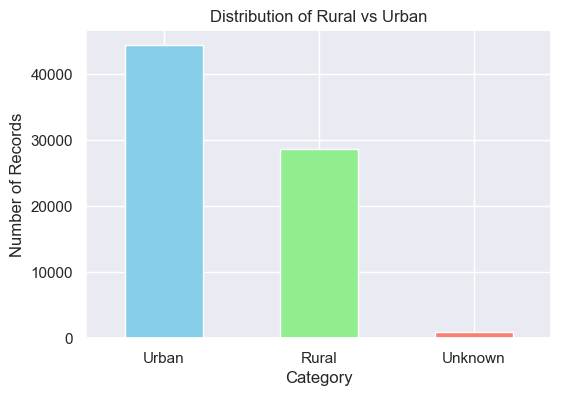

In [17]:
# Define a mapping dictionary
rural_urban_map = {
    "R": "Rural",
    "U": "Urban",
    "": "Unknown" # handle empty strings
}

# Apply mapping
hospital_provider_cost_data_clean["Rural Versus Urban"] = (
    hospital_provider_cost_data_clean["Rural Versus Urban"]
    .fillna("Unknown")              # replace NaN with "Unknown"
    .replace(rural_urban_map)       # apply mapping
)

# Check results
print(hospital_provider_cost_data_clean["Rural Versus Urban"].value_counts())
print(hospital_provider_cost_data_clean["Rural Versus Urban"].unique())

# Visualize results with a bar chart
counts = hospital_provider_cost_data_clean["Rural Versus Urban"].value_counts()
plt.figure(figsize=(6,4))
counts.plot(kind="bar", color=["skyblue", "lightgreen", "salmon"])
plt.title("Distribution of Rural vs Urban")
plt.xlabel("Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

The bar chart below shows the count of records in the dataset classified as **Rural**, **Urban**, or **Unknown**. This cleaning ensures that the **Rural Versus Urban** column is standardized and can now be reliably used for data analysis, such as comparing hospital costs, utilization, or outcomes across rural and urban areas.

---
#### CCN Facility Type Column Cleaning

The CCN Facility Type column originally contained coded acronyms (e.g., STH, CAH, LTCH) that were not easily interpretable. To improve readability while preserving the original values, I created a lookup table mapping each acronym to its full description. A new column, CCN Facility Type Description, was added directly next to the acronym column so both the raw code and human-readable label are available.

This approach ensures:
- Acronyms are retained for technical accuracy and dataset joins.
- Descriptions provide clarity for analysis, visualization, and stakeholder reporting.

In [18]:
# Read CCN Facility Type lookup file
ccn_lookup = pd.read_csv("../Data/lookups/CCN Facility Type Lookup.csv", encoding="latin1")

# Convert to dictionary
ccn_facility_type_map = dict(zip(ccn_lookup["CCN Facility Type Acronym"], ccn_lookup["CCN Facility Type Description"]))

# Apply mapping and create the new column
hospital_provider_cost_data_clean["CCN Facility Type Description"] = (hospital_provider_cost_data_clean["CCN Facility Type"].map(ccn_facility_type_map).fillna("Unknown"))

# Reorder columns so description is right after "CCN Facility Type"
cols = list(hospital_provider_cost_data_clean.columns)

# find the index of "CCN Facility Type"
idx = cols.index("CCN Facility Type")

# move "CCN Facility Type Description" right after it
cols.insert(idx + 1, cols.pop(cols.index("CCN Facility Type Description")))

# reassign reordered DataFrame
hospital_provider_cost_data_clean = hospital_provider_cost_data_clean[cols]

# Check results
hospital_provider_cost_data_clean.sample(5, random_state=42)


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,CCN Facility Type Description,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
17005,723653,131304,POWER COUNTY HOSPITAL DISTRICT,510 ROOSEVELT,AMERICAN FALLS,ID,83211,POWER,99913.0,Rural,CAH,Critical Access Hospitals,1,11,10/1/2019,9/30/2020,66.41,NaN,NaN,445.0,3.0,559.0,7.0,3156.0,NaN,33.0,1.0,52.0,23.0,NaN,103.0,3.0,166.0,7.0,3156.0,NaN,33.0,1.0,52.0,3.56e+02,2.47e+05,2.99e+05,8.82e+05,5.13e+06,5.23e+06,1.02e+06,9.95e+06,2.88e+06,5.37e+06,8.25e+06,NaN,NaN,NaN,NaN,NaN,NaN,7.26e+06,NaN,NaN,1.67e+06,-5.48e+05,1.62e+05,9.80e+04,NaN,1.09e+07,1.96e+05,2.01e+04,1.61e+07,NaN,2.71e+05,2.53e+06,NaN,NaN,1.55e+07,NaN,1.24e+05,1.24e+05,2.66e+07,1.14e+06,5.08e+05,NaN,NaN,5.44e+06,NaN,7.09e+06,NaN,NaN,NaN,1.53e+07,1.53e+07,2.23e+07,4.26e+06,4.26e+06,2.66e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.88e+06,6.38e+06,9.25e+06,7.63e+05,8.49e+06,1.04e+07,-1.88e+06,2.36e+06,4.84e+05,NaN,4.84e+05,1.21,1.96e+06,2.11e+06,NaN

---
#### Provider Type Column Cleaning

The Provider Type column originally contained coded labels that were not easily interpretable. To improve readability while preserving the original values, I created a lookup table mapping each code to its full description. A new column, Provider Type Description, was added directly next to the original column so both the raw code and human-readable label are available.

This approach ensures:
- Original provider type codes are retained for technical accuracy and potential dataset joins.
- Descriptions provide clarity for analysis, visualization, and stakeholder reporting.

In [19]:
# Read Provider Type lookup file
provider_lookup = pd.read_csv("../Data/lookups/Provider Type Lookup.csv", encoding="latin1")

# Convert to dictionary
provider_type_map = dict(zip(provider_lookup["Provider Type"], provider_lookup["Provider Type Description"]))

# Apply mapping and create the new column
hospital_provider_cost_data_clean["Provider Type Description"] = (hospital_provider_cost_data_clean["Provider Type"].map(provider_type_map).fillna("Unknown"))

# Reorder columns so description is right after "Provider Type"
cols = list(hospital_provider_cost_data_clean.columns)

# find the index of "Provider Type"
idx = cols.index("Provider Type")

# move "Provider Type Description" right after it
cols.insert(idx + 1, cols.pop(cols.index("Provider Type Description")))

# reassign reordered DataFrame
hospital_provider_cost_data_clean = hospital_provider_cost_data_clean[cols]

# Check results
hospital_provider_cost_data_clean.sample(5, random_state=42)

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,CCN Facility Type Description,Provider Type,Provider Type Description,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
17005,723653,131304,POWER COUNTY HOSPITAL DISTRICT,510 ROOSEVELT,AMERICAN FALLS,ID,83211,POWER,99913.0,Rural,CAH,Critical Access Hospitals,1,General Short Term (includes CAHs),11,10/1/2019,9/30/2020,66.41,NaN,NaN,445.0,3.0,559.0,7.0,3156.0,NaN,33.0,1.0,52.0,23.0,NaN,103.0,3.0,166.0,7.0,3156.0,NaN,33.0,1.0,52.0,3.56e+02,2.47e+05,2.99e+05,8.82e+05,5.13e+06,5.23e+06,1.02e+06,9.95e+06,2.88e+06,5.37e+06,8.25e+06,NaN,NaN,NaN,NaN,NaN,NaN,7.26e+06,NaN,NaN,1.67e+06,-5.48e+05,1.62e+05,9.80e+04,NaN,1.09e+07,1.96e+05,2.01e+04,1.61e+07,NaN,2.71e+05,2.53e+06,NaN,NaN,1.55e+07,NaN,1.24e+05,1.24e+05,2.66e+07,1.14e+06,5.08e+05,NaN,NaN,5.44e+06,NaN,7.09e+06,NaN,NaN,NaN,1.53e+07,1.53e+07,2.23e+07,4.26e+06,4.26e+06,2.66e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.88e+06,6.38e+06,9.25e+06,7.63e+05,8.49e+06,1.04e+07,-1.88e

---
#### Type of Control Column Cleaning

The Type of Control column originally contained coded labels that were not easily interpretable. To improve readability while preserving the original values, I created a lookup table mapping each code to its full description. A new column, Type of Control Description, was added directly next to the original column so both the raw code and human-readable label are available.

This approach ensures:
- Original Type of Control codes are retained for technical accuracy and potential dataset joins.
- Descriptions provide clarity for analysis, visualization, and stakeholder reporting.

In [20]:
# Read Type of Control lookup file
control_lookup = pd.read_csv("../Data/lookups/Type of Control Lookup.csv", encoding="utf-8")

# Convert to dictionary
control_type_map = dict(zip(control_lookup["Type of Control Code"], control_lookup["Type of Control Description"]))

# Apply mapping and create the new column
hospital_provider_cost_data_clean["Type of Control Description"] = (hospital_provider_cost_data_clean["Type of Control"].map(control_type_map).fillna("Unknown"))

# Reorder columns so description is right after "Type of Control"
cols = list(hospital_provider_cost_data_clean.columns)
idx = cols.index("Type of Control")
cols.insert(idx + 1, cols.pop(cols.index("Type of Control Description")))

# Reassign reordered DataFrame
hospital_provider_cost_data_clean = hospital_provider_cost_data_clean[cols]

# Check results
hospital_provider_cost_data_clean.sample(5, random_state=42)

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,CCN Facility Type Description,Provider Type,Provider Type Description,Type of Control,Type of Control Description,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,Cost Report Year
17005,723653,131304,POWER COUNTY HOSPITAL DISTRICT,510 ROOSEVELT,AMERICAN FALLS,ID,83211,POWER,99913.0,Rural,CAH,Critical Access Hospitals,1,General Short Term (includes CAHs),11,Governmental/Hospital District,10/1/2019,9/30/2020,66.41,NaN,NaN,445.0,3.0,559.0,7.0,3156.0,NaN,33.0,1.0,52.0,23.0,NaN,103.0,3.0,166.0,7.0,3156.0,NaN,33.0,1.0,52.0,3.56e+02,2.47e+05,2.99e+05,8.82e+05,5.13e+06,5.23e+06,1.02e+06,9.95e+06,2.88e+06,5.37e+06,8.25e+06,NaN,NaN,NaN,NaN,NaN,NaN,7.26e+06,NaN,NaN,1.67e+06,-5.48e+05,1.62e+05,9.80e+04,NaN,1.09e+07,1.96e+05,2.01e+04,1.61e+07,NaN,2.71e+05,2.53e+06,NaN,NaN,1.55e+07,NaN,1.24e+05,1.24e+05,2.66e+07,1.14e+06,5.08e+05,NaN,NaN,5.44e+06,NaN,7.09e+06,NaN,NaN,NaN,1.53e+07,1.53e+07,2.23e+07,4.26e+06,4.26e+06,2.66e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2

---
#### Financial & Operational Column Cleaning

This section addresses columns containing financial, operational, and categorical data that require cleaning, standardization, or mapping to descriptive labels. The goal is to ensure clarity, consistency, and readiness for analysis and visualization.  

Below, fields are grouped by category.  
- **Line Items** → Safe to standardize (e.g., flip negatives to positives).  
- **Reported Totals** → Should not be flipped or recalculated unless official definitions are available.  

Assets
- Cash on Hand and in Banks  
- Temporary Investments  
- Notes Receivable  
- Accounts Receivable  
- Inventory  
- Prepaid Expenses  
- Other Current Assets  
- Land  
- Land Improvements  
- Buildings  
- Leasehold Improvements  
- Fixed Equipment  
- Major Movable Equipment  
- Minor Equipment Depreciable  
- Health IT Designated Assets  
- Investments  
- Other Assets  

**Reported Totals (do not recalc)**
- Total Current Assets  
- Total Fixed Assets  
- Total Other Assets  
- Total Assets  

Liabilities
- Accounts Payable  
- Salaries, Wages, and Fees Payable  
- Payroll Taxes Payable  
- Notes and Loans Payable (Short Term)  
- Deferred Income  
- Other Current Liabilities  
- Mortgage Payable  
- Notes Payable  
- Unsecured Loans  
- Other Long Term Liabilities  

**Reported Totals (do not recalc)**
- Total Current Liabilities  
- Total Long Term Liabilities  
- Total Liabilities  
- Total Fund Balances  
- Total Liabilities and Fund Balances  

Revenue & Expenses
- Managed Care Simulated Payments  
- Inpatient Revenue  
- Outpatient Revenue  
- Net Revenue from Medicaid  
- Medicaid Charges  
- Net Revenue from Stand-Alone CHIP  
- Stand-Alone CHIP Charges  
- Cost of Charity Care  
- Cost of Uncompensated Care  

**Reported Totals (do not recalc)**
- Less Total Operating Expense  
- Total Other Income  
- Total Other Expenses  
- Total Unreimbursed and Uncompensated Care  

In [21]:
# List of columns to flip
cols_to_flip = [
    "Cost of Charity Care",
    "Cost of Uncompensated Care",
    "Cash on Hand and in Banks",
    "Temporary Investments",
    "Notes Receivable",
    "Accounts Receivable",
    "Inventory",
    "Prepaid Expenses",
    "Other Current Assets",
    "Land",
    "Land Improvements",
    "Buildings",
    "Leasehold Improvements",
    "Fixed Equipment",
    "Major Movable Equipment",
    "Minor Equipment Depreciable",
    "Health Information Technology Designated Assets",
    "Investments",
    "Other Assets",
    "Accounts Payable",
    "Salaries, Wages, and Fees Payable",
    "Payroll Taxes Payable",
    "Notes and Loans Payable (Short Term)",
    "Deferred Income",
    "Other Current Liabilities",
    "Mortgage Payable",
    "Notes Payable",
    "Unsecured Loans",
    "Other Long Term Liabilities",
    "Managed Care Simulated Payments",
    "Inpatient Revenue",
    "Outpatient Revenue",
    "Net Revenue from Medicaid",
    "Medicaid Charges",
    "Net Revenue from Stand-Alone CHIP",
    "Stand-Alone CHIP Charges"
]

# Flip values to positive
hospital_provider_cost_data_clean[cols_to_flip] = (hospital_provider_cost_data_clean[cols_to_flip].abs())

# Quick check
print(hospital_provider_cost_data_clean[cols_to_flip].min())

Cost of Charity Care                                1.0
Cost of Uncompensated Care                          1.0
Cash on Hand and in Banks                           1.0
Temporary Investments                               0.0
Notes Receivable                                    1.0
Accounts Receivable                                28.0
Inventory                                           1.0
Prepaid Expenses                                    1.0
Other Current Assets                                1.0
Land                                                1.0
Land Improvements                                   1.0
Buildings                                           1.0
Leasehold Improvements                              1.0
Fixed Equipment                                     1.0
Major Movable Equipment                             1.0
Minor Equipment Depreciable                         1.0
Health Information Technology Designated Assets     1.0
Investments                                     

The purpose of this code is to standardize financial and revenue/expense line-item columns by converting any negative values (due to accounting conventions such as credits or expense reporting) to positive values. This ensures consistency, avoids misinterpretation in analysis and visualization, and keeps pre-calculated totals untouched.

---
### Exploratory Data Analysis (EDA)

This section provides an initial exploration of the hospital cost report dataset to identify key trends, distributions, and relationships. The goal is to uncover patterns in hospital financial performance, operational capacity, and care delivery, while identifying outliers or anomalies that may impact subsequent analysis.

The analysis is guided by the following research questions:
1. **Financial Performance** – Understand trends in net income, cost-to-charge ratios, and differences across urban vs. rural hospitals, as well as long-term changes in assets, liabilities, and fund balances
2. **Capacity & Operations** – Examine hospital capacity by state and county, including bed counts, patient days, and staffing relative to patient volume
3. **Care Delivery & Equity** – Assess trends in charity care and uncompensated care, as well as revenue differences between inpatient and outpatient services by hospital type and size

To ensure clarity and reproducibility, our exploratory analysis will follow a structured approach for each research question:
1. **Explain the Question** – Clearly describe what we are investigating and why it matters
2. **Describe the Method** – Outline how the analysis will be performed, using methods such as groupby, aggregations, or ratio calculations. 
3. **Show Code & Visuals** – Present Python code and visualizations to illustrate results
4. **Document Observations** – Highlight trends, outliers, or any surprising findings

This structured approach ensures that each analysis step is transparent, reproducible, and directly tied to the research questions, providing a solid foundation for deeper analysis and visualization.

#### 1. How has hospital net income changed over time, both nationally and by state?

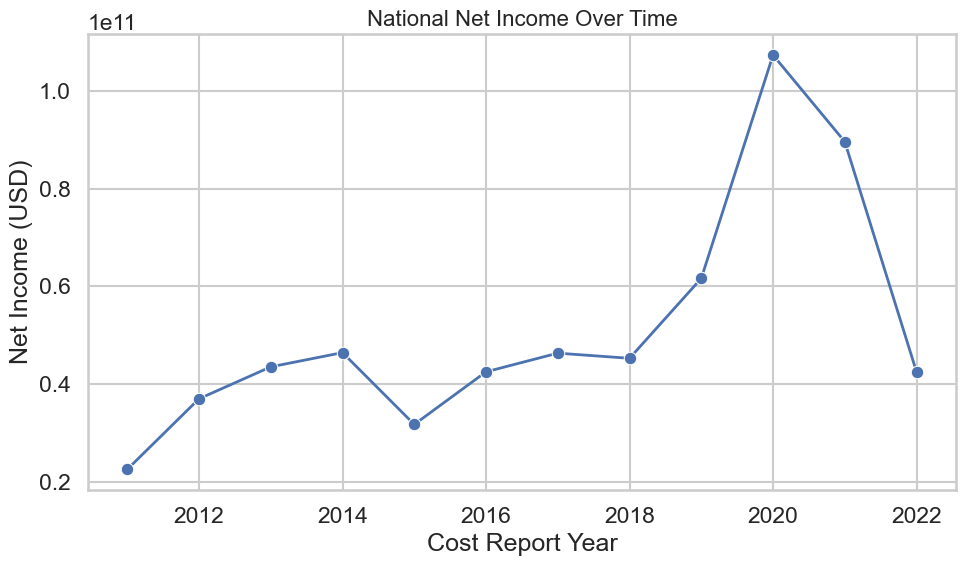

In [ ]:
# Columns: ['Cost Report Year', 'State Code', 'Net Income']
sns.set(style="whitegrid", context="talk")
national_net_income = hospital_provider_cost_data_clean.groupby('Cost Report Year')['Net Income'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=national_net_income, x='Cost Report Year', y='Net Income', marker='o', linewidth=2)
plt.title('National Net Income Over Time', fontsize=16)
plt.xlabel('Cost Report Year')
plt.ylabel('Net Income (USD)')
plt.tight_layout()
plt.show()

Some key observations include:
- 2011–2018: Gradual increase in profitability, possibly reflecting post-recession recovery and policy stabilization after the Affordable Care Act (ACA) rollout.
- 2019–2020: A dramatic jump — likely related to COVID-19 relief funding (CARES Act and other federal assistance). Many hospitals recorded unusually high revenues in 2020 due to emergency funding rather than normal operations.
- 2021–2022: Noticeable decline — as relief funding tapered and hospitals faced higher operating costs (labor shortages, inflation, deferred care returning).
- Despite fluctuations, the overall long-term trend remains positive relative to 2011, suggesting hospital sector growth over the decade.

Summary:
- From 2011 to 2019, hospital net income increased steadily, reflecting improving financial health in the U.S. hospital sector. A sharp spike in 2020 coincides with federal COVID-19 relief funds, followed by a decline in 2021–2022 as emergency support decreased and operational costs rose.

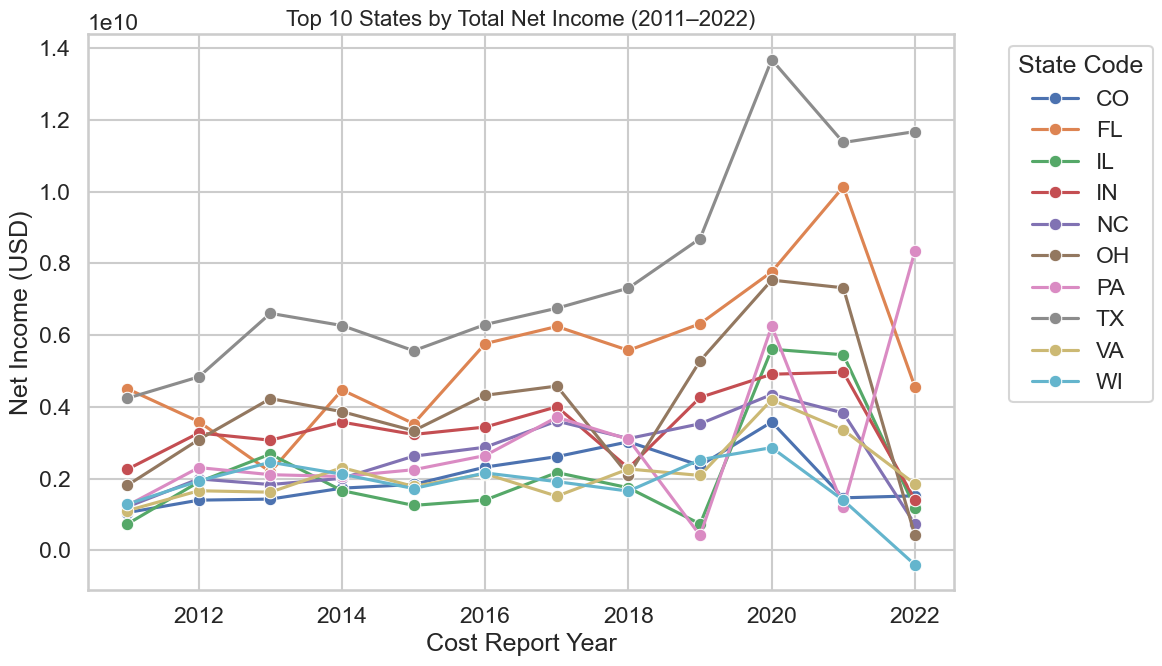

In [ ]:
# Compute top 10 states by total net income across all years
top_states = (hospital_provider_cost_data_clean.groupby('State Code')['Net Income'].sum().nlargest(10).index)

# Filter to only those states
df_top_states = hospital_provider_cost_data_clean[hospital_provider_cost_data_clean['State Code'].isin(top_states)]

# Compute yearly totals
state_net_income = (df_top_states.groupby(['Cost Report Year', 'State Code'])['Net Income'].sum().reset_index())

plt.figure(figsize=(12,7))
sns.lineplot(data=state_net_income,x='Cost Report Year',y='Net Income',hue='State Code',marker='o')
plt.title('Top 10 States by Total Net Income (2011–2022)', fontsize=16)
plt.xlabel('Cost Report Year')
plt.ylabel('Net Income (USD)')
plt.legend(title='State Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Some key observations include:
- Texas (TX) consistently leads all states in total hospital net income across the entire period, showing a steady rise from 2011 to a sharp peak in 2020, likely due to COVID-19-related funding surges.
- Florida (FL) and Ohio (OH) follow as strong performers, both showing similar upward trends until 2020 before moderating in 2021–2022.
- Most states exhibit a pronounced spike in 2020, corresponding to federal relief payments and temporary reimbursement adjustments during the pandemic.
- The post-2020 decline across nearly all states indicates the reduction of emergency support and the return to typical operating margins.
- Despite short-term fluctuations, the long-term trend from 2011–2019 is positive, suggesting gradual strengthening of hospital financial performance prior to the pandemic.
- A few states (e.g., Pennsylvania, Illinois, North Carolina) show notable year-to-year volatility, which may reflect shifts in system consolidations, mergers, or state-level policy differences.

Summary: 
- The overall picture shows broad financial improvement across major states up to 2019, a dramatic but temporary profit surge in 2020, and a normalization phase afterward — with Texas and Florida remaining the top contributors to national hospital profitability.

#### 2. What is the average cost-to-charge ratio across hospitals, and which hospitals are outliers?

Average Cost-to-Charge Ratio: 0.39


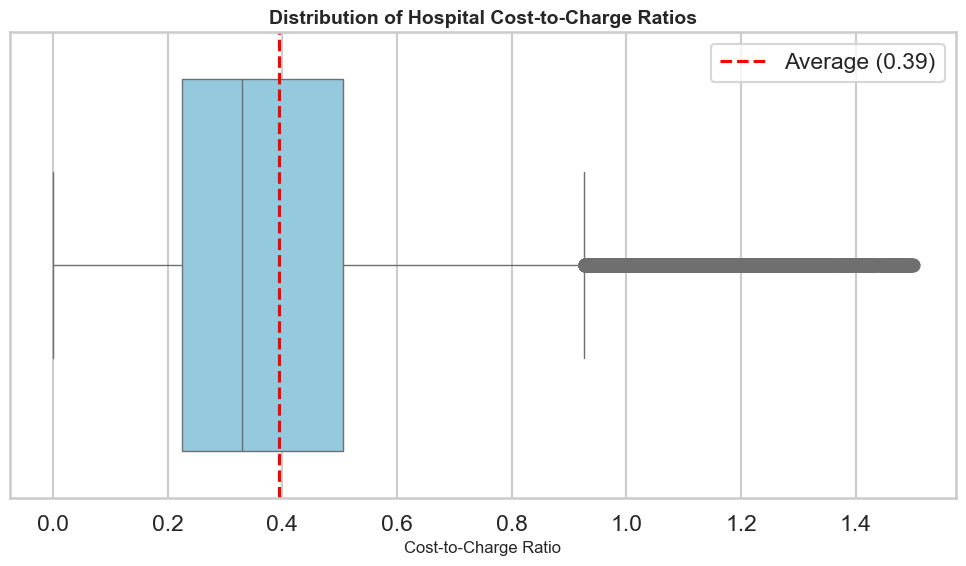

Number of Outlier Hospitals: 2889


,Provider CCN,Hospital Name,Cost to Charge Ratio
1018,10172,NORTH ALABAMA SPECIALTY HOSPITAL,1.17
1198,13027,MERCY MEDICAL,0.95
1199,13027,MOBILE BAY RAHABILITATION HOSPITAL,1.00
1200,13027,MOBILE BAY REHABILITATION HOSPITAL,0.95
1318,14007,BRYCE HOSPITAL,0.99
1323,14007,BRYCE HOSPITAL,0.93
1325,14007,BRYCE HOSPITAL,0.98
1326,14007,BRYCE HOSPITAL,1.15
1331,14009,NORTH ALABAMA REGIONAL HOSPITAL,1.18
1333,14009,NORTH ALABAMA REGIONAL HOSPITAL,1.06


In [47]:
# Replace commas and dollar signs if they exist, then convert to float
cols = ['Total Costs', 'Combined Outpatient + Inpatient Total Charges']
for c in cols:
    hospital_provider_cost_data_clean[c] = (
        hospital_provider_cost_data_clean[c]
        .astype(str)
        .str.replace('[\$,]', '', regex=True)
        .replace('', '0')  # handle blanks
        .astype(float)
    )

# --- 2. Compute cost-to-charge ratio safely ---
hospital_provider_cost_data_clean = hospital_provider_cost_data_clean[
    hospital_provider_cost_data_clean['Combined Outpatient + Inpatient Total Charges'] > 0
]

hospital_provider_cost_data_clean['Cost to Charge Ratio'] = (
    hospital_provider_cost_data_clean['Total Costs'] /
    hospital_provider_cost_data_clean['Combined Outpatient + Inpatient Total Charges']
)

# --- 3. Filter out invalid or unrealistic ratios ---
hospital_provider_cost_data_clean = hospital_provider_cost_data_clean[
    hospital_provider_cost_data_clean['Cost to Charge Ratio'].between(0, 1.5)
]

# --- 4. Calculate and print average ratio ---
avg_ccr = hospital_provider_cost_data_clean['Cost to Charge Ratio'].mean()
print(f"Average Cost-to-Charge Ratio: {avg_ccr:.2f}")

# --- 5. Boxplot visualization ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=hospital_provider_cost_data_clean, x='Cost to Charge Ratio', color='skyblue')
plt.title("Distribution of Hospital Cost-to-Charge Ratios", fontsize=14, weight='bold')
plt.xlabel("Cost-to-Charge Ratio", fontsize=12)
plt.axvline(avg_ccr, color='red', linestyle='--', label=f'Average ({avg_ccr:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

# --- 6. Identify outliers using IQR ---
Q1 = hospital_provider_cost_data_clean['Cost to Charge Ratio'].quantile(0.25)
Q3 = hospital_provider_cost_data_clean['Cost to Charge Ratio'].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (
    (hospital_provider_cost_data_clean['Cost to Charge Ratio'] < (Q1 - 1.5 * IQR)) |
    (hospital_provider_cost_data_clean['Cost to Charge Ratio'] > (Q3 + 1.5 * IQR))
)
outliers = hospital_provider_cost_data_clean[outlier_mask]

print(f"Number of Outlier Hospitals: {len(outliers)}")
outliers[['Provider CCN', 'Hospital Name', 'Cost to Charge Ratio']].head(10)

Some key observations include: 
- The average cost-to-charge ratio across hospitals is approximately 0.39, meaning that, on average, hospitals spend about 39 cents for every dollar they bill.
- The distribution is right-skewed, with most hospitals clustered below the mean and a few hospitals showing unusually high ratios, indicating potential inefficiencies or differences in cost structures.
- Outliers in the data may represent specialty hospitals, rural facilities, or organizations operating under alternative reimbursement systems.
- This ratio provides a useful benchmark for comparing efficiency trends over time or across different hospital types.

Summary:
- The cost-to-charge ratio analysis reveals that hospitals, on average, spend about 39% of each billed dollar. Most hospitals cluster below this average, while a small number of outliers have substantially higher ratios, resulting in a right-skewed distribution. Understanding these patterns helps identify efficiency trends and provides a benchmark for comparing hospital performance across types and over time.

#### 3. How has the cost-to-charge ratio evolved over the years?

#### 4. How do urban vs. rural hospitals differ in financial performance trends?

#### 5. What are the long-term trends in assets, liabilities, and fund balances?

#### 6. Which states or counties have the highest hospital capacity in terms of beds and patient days?

#### 7. How has staffing (FTE employees) changed relative to patient volume?

#### 8. What are the trends in charity care and uncompensated care over time?

#### 9. How much uncompensated care is provided by region or hospital type?

#### 10. How do inpatient vs. outpatient revenues vary by hospital size and type?

### Key Findings / Insights

### Limitations

### Next Steps / Future Work